# 📊 Telco Customer Churn Prediction

## 🎯 Objectif
Identifier les clients à risque de churn et proposer
des actions marketing ciblées pour les retenir.

## 🔍 Résultats clés
- Modèle : Régression Logistique (seuil optimisé 0.45)
- AUC-ROC : 0.843 (cross-validation 5-fold)
- Recall Churn : 82% — 307/374 churners détectés
- 1756 clients identifiés comme critiques (priorité immédiate)

## 🛠️ Technologies
Python | Pandas | Scikit-learn | XGBoost | Seaborn | Matplotlib

## 📌 Insights principaux
- Les contrats mensuels ont 42% de taux de churn
- Les clients Fiber optic churned à 41%
- Le tenure court (0-10 mois) = signal le plus fort

## 🚀 Lancer le projet
pip install -r requirements.txt

In [43]:
!pip install xgboost -q


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')


In [4]:
df = pd.read_csv(r"C:\Users\MEROUA\Desktop\Le_Churn\data\data.csv")

In [5]:
# Option pour afficher toutes les colonnes
pd.set_option('display.max_columns', None)

# Afficher le head
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.tail(5) 

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [7]:
print(f"Lignes : {df.shape[0]}")
print(f"Colonnes : {df.shape[1]}")
print(f"Taille : {df.shape}")


Lignes : 7043
Colonnes : 21
Taille : (7043, 21)


In [8]:
print(df.columns.tolist())

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [10]:
# 1. Voir les valeurs problématiques
mask = pd.to_numeric(df['TotalCharges'], errors='coerce').isna()
print(df[mask]['TotalCharges'].value_counts())

# 2. Compter combien de valeurs sont concernées
print("Valeurs non convertibles :", mask.sum())

# 3. Corriger : convertir en float (les valeurs invalides → NaN)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# 4. Vérifier le résultat
print(df['TotalCharges'].dtype)
print(df['TotalCharges'].isna().sum(), "valeurs NaN après conversion")

TotalCharges
    11
Name: count, dtype: int64
Valeurs non convertibles : 11
float64
11 valeurs NaN après conversion


# Voir les lignes concernées
df_nan = df[df['TotalCharges'].isna()]
print(df_nan[['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']])

In [11]:
# Remplacer les NaN par 0 (logique : aucun mois facturé)
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Vérification finale
print(df['TotalCharges'].isna().sum())  
print(df['TotalCharges'].dtype)         

0
float64


 # Types de chaque colonne

In [12]:
print(df.dtypes)
print("\nRésumé des types :")
print(df.dtypes.value_counts())

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

Résumé des types :
object     17
int64       2
float64     2
Name: count, dtype: int64


# Colonnes catégorielles — valeurs uniques

In [13]:
cat_cols = df.select_dtypes(include='object').columns.tolist()

for col in cat_cols:
    vals = df[col].unique()
    print(f"\n{col} ({len(vals)} valeurs uniques) :")
    print(vals)


customerID (7043 valeurs uniques) :
['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']

gender (2 valeurs uniques) :
['Female' 'Male']

Partner (2 valeurs uniques) :
['Yes' 'No']

Dependents (2 valeurs uniques) :
['No' 'Yes']

PhoneService (2 valeurs uniques) :
['No' 'Yes']

MultipleLines (3 valeurs uniques) :
['No phone service' 'No' 'Yes']

InternetService (3 valeurs uniques) :
['DSL' 'Fiber optic' 'No']

OnlineSecurity (3 valeurs uniques) :
['No' 'Yes' 'No internet service']

OnlineBackup (3 valeurs uniques) :
['Yes' 'No' 'No internet service']

DeviceProtection (3 valeurs uniques) :
['No' 'Yes' 'No internet service']

TechSupport (3 valeurs uniques) :
['No' 'Yes' 'No internet service']

StreamingTV (3 valeurs uniques) :
['No' 'Yes' 'No internet service']

StreamingMovies (3 valeurs uniques) :
['No' 'Yes' 'No internet service']

Contract (3 valeurs uniques) :
['Month-to-month' 'One year' 'Two year']

PaperlessBilling (2 valeurs uniques) :
['Yes' 'N

# Colonnes numériques — aperçu statistique

In [14]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Colonnes numériques :", num_cols)

df[num_cols].describe()

Colonnes numériques : ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


#  Variable cible — distribution du Churn

In [15]:
print(df['Churn'].value_counts())
print("\nEn pourcentage :")
print(df['Churn'].value_counts(normalize=True).round(3) * 100)

Churn
No     5174
Yes    1869
Name: count, dtype: int64

En pourcentage :
Churn
No     73.5
Yes    26.5
Name: proportion, dtype: float64


# Colonne ID — vérifier l'unicité

In [16]:
print("customerID uniques :", df['customerID'].nunique())
print("Total lignes :", len(df))
# Si égaux → pas de doublons sur l'ID

customerID uniques : 7043
Total lignes : 7043


In [17]:
# Doublons sur toutes les colonnes
print("Doublons totaux :", df.duplicated().sum())

# Doublons sur customerID uniquement
print("Doublons customerID :", df.duplicated(subset='customerID').sum())

Doublons totaux : 0
Doublons customerID : 0


# Valeurs manquantes

In [18]:
# Compter les NaN par colonne
missing = df.isnull().sum()
print(missing[missing > 0])

# Pourcentage
print("\nEn pourcentage :")
print((df.isnull().sum() / len(df) * 100).round(2))

Series([], dtype: int64)

En pourcentage :
customerID          0.0
gender              0.0
SeniorCitizen       0.0
Partner             0.0
Dependents          0.0
tenure              0.0
PhoneService        0.0
MultipleLines       0.0
InternetService     0.0
OnlineSecurity      0.0
OnlineBackup        0.0
DeviceProtection    0.0
TechSupport         0.0
StreamingTV         0.0
StreamingMovies     0.0
Contract            0.0
PaperlessBilling    0.0
PaymentMethod       0.0
MonthlyCharges      0.0
TotalCharges        0.0
Churn               0.0
dtype: float64


#  Outliers sur les colonnes numériques (méthode IQR)

In [19]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col} → borne [{lower:.1f}, {upper:.1f}] — {len(outliers)} outliers")

tenure → borne [-60.0, 124.0] — 0 outliers
MonthlyCharges → borne [-46.0, 171.4] — 0 outliers
TotalCharges → borne [-4683.5, 8868.7] — 0 outliers


# Nettoyage — valeurs redondantes

In [20]:
# Colonnes avec "No internet service" → remplacer par "No"
cols_internet = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                 'TechSupport', 'StreamingTV', 'StreamingMovies']
for col in cols_internet:
    df[col] = df[col].replace('No internet service', 'No')
df['MultipleLines'] = df['MultipleLines'].replace('No phone service', 'No')


# Vérification finale

In [21]:
cat_cols = df.select_dtypes(include='object').columns.tolist()

for col in cat_cols:
    vals = df[col].unique()
    print(f"\n{col} ({len(vals)} valeurs uniques) :")
    print(vals)


customerID (7043 valeurs uniques) :
['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']

gender (2 valeurs uniques) :
['Female' 'Male']

Partner (2 valeurs uniques) :
['Yes' 'No']

Dependents (2 valeurs uniques) :
['No' 'Yes']

PhoneService (2 valeurs uniques) :
['No' 'Yes']

MultipleLines (2 valeurs uniques) :
['No' 'Yes']

InternetService (3 valeurs uniques) :
['DSL' 'Fiber optic' 'No']

OnlineSecurity (2 valeurs uniques) :
['No' 'Yes']

OnlineBackup (2 valeurs uniques) :
['Yes' 'No']

DeviceProtection (2 valeurs uniques) :
['No' 'Yes']

TechSupport (2 valeurs uniques) :
['No' 'Yes']

StreamingTV (2 valeurs uniques) :
['No' 'Yes']

StreamingMovies (2 valeurs uniques) :
['No' 'Yes']

Contract (3 valeurs uniques) :
['Month-to-month' 'One year' 'Two year']

PaperlessBilling (2 valeurs uniques) :
['Yes' 'No']

PaymentMethod (4 valeurs uniques) :
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']

Churn (2 valeurs u

In [22]:
print(df.dtypes)
print("\nValeurs manquantes restantes :", df.isnull().sum().sum())

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

Valeurs manquantes restantes : 0


# EDA (Analyse Exploratoire) 

In [23]:
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

# Distribution des variables numériques

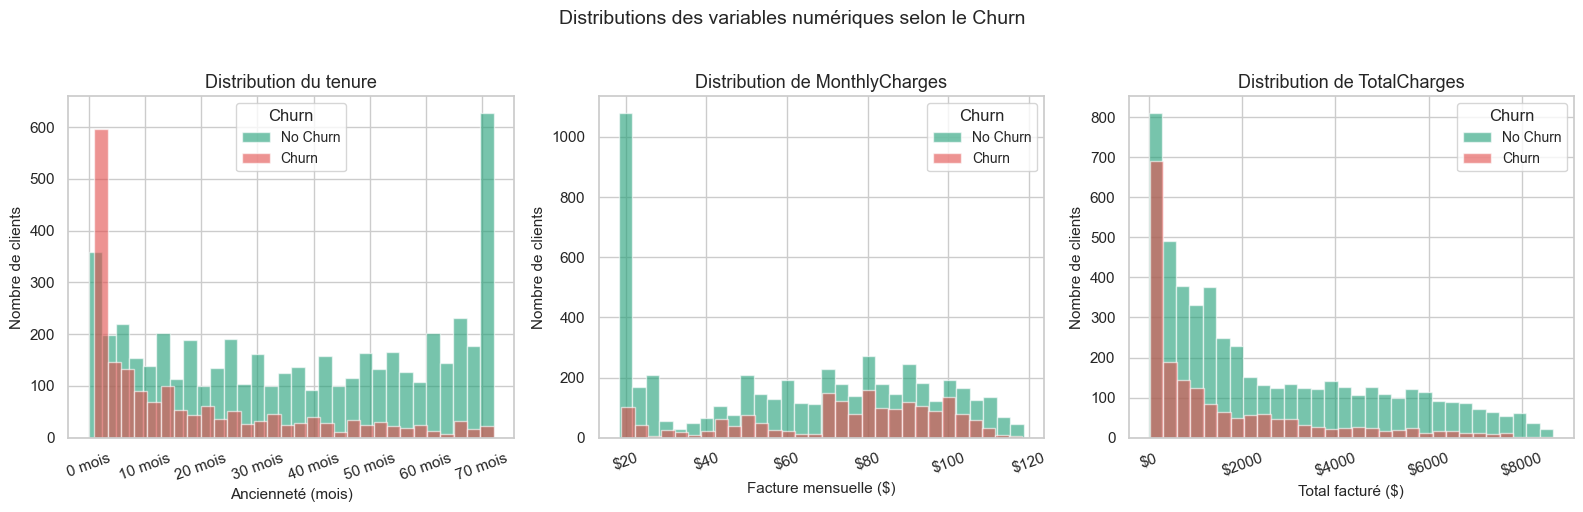

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Colonnes + unités associées
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
xlabels = ['Ancienneté (mois)', 'Facture mensuelle ($)', 'Total facturé ($)']
titles = ['Distribution du tenure', 'Distribution de MonthlyCharges', 'Distribution de TotalCharges']
for i, col in enumerate(num_cols):
    no_churn = df[df['Churn'] == 'No'][col]
    yes_churn = df[df['Churn'] == 'Yes'][col]

    axes[i].hist(no_churn, bins=30, alpha=0.6, color='#1D9E75', label='No Churn')
    axes[i].hist(yes_churn, bins=30, alpha=0.6, color='#E24B4A', label='Churn')

    axes[i].set_title(titles[i], fontsize=13)
    axes[i].set_xlabel(xlabels[i], fontsize=11)
    axes[i].set_ylabel('Nombre de clients', fontsize=11)
    axes[i].legend(title='Churn', fontsize=10)
     # Formatter l'axe X selon la colonne
    if col == 'tenure':
        axes[i].xaxis.set_major_formatter(
            plt.FuncFormatter(lambda x, _: f'{int(x)} mois'))
    else:
        axes[i].xaxis.set_major_formatter(
            plt.FuncFormatter(lambda x, _: f'${int(x)}'))

    axes[i].tick_params(axis='x', rotation=20)

plt.suptitle('Distributions des variables numériques selon le Churn',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Graphique 1 — tenure
- Les clients quittent généralement **avant 10 mois**.
- Après 10 mois, la fidélité augmente progressivement.
- À 70 mois, **presque personne ne churn**.

### Graphique 2 — MonthlyCharges (facture mensuelle)
plus la facture mensuelle est élevée, plus le risque de churn augmente

### Graphique 3 — TotalCharges (total cumulé)
- La barre rouge est très haute entre 0 et 500 puis disparaît rapidement
- La barre verte reste présente jusqu'à 8000
- les clients qui churned n'ont pas eu le temps d'accumuler beaucoup — c'est une conséquence directe du graphique 1 (tenure court = TotalCharges faible)

# Churn par variables catégorielles clés

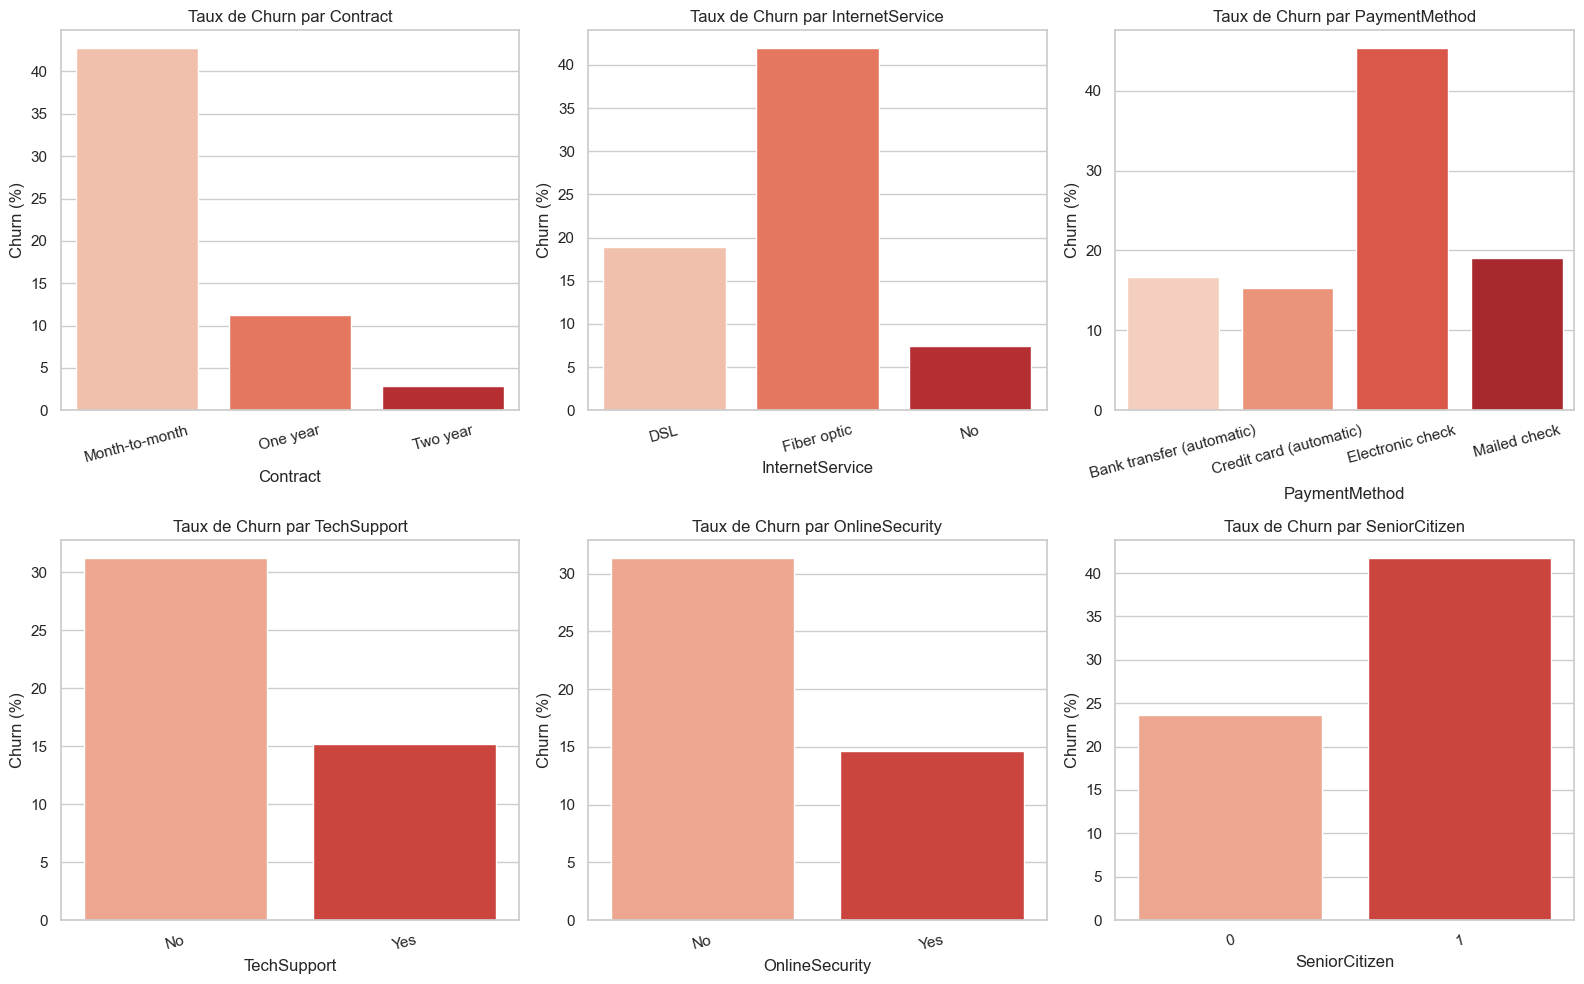

In [25]:
cat_cols = ['Contract', 'InternetService', 'PaymentMethod',
            'TechSupport', 'OnlineSecurity', 'SeniorCitizen']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    churn_rate = df.groupby(col)['Churn'].apply(
        lambda x: (x == 'Yes').mean() * 100).reset_index()
    churn_rate.columns = [col, 'Churn_Rate']
    sns.barplot(data=churn_rate, x=col, y='Churn_Rate',
                palette='Reds', ax=axes[i])
    axes[i].set_title(f'Taux de Churn par {col}')
    axes[i].set_ylabel('Churn (%)')
    axes[i].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

### Contract — le signal le plus fort
- Month-to-month : ~42% de churn — énorme !
- One year : ~11%, Two year : ~3%
- les clients sans engagement partent massivement. L'engagement long terme fidélise très fortement

###  InternetService
- Fiber optic : ~41% de churn — très élevé
- DSL : ~19%, No : ~7%
- paradoxalement, le service le plus rapide est le moins fidèle — probablement trop cher ou concurrence forte sur ce segment

### PaymentMethod
- Electronic check : ~45% — le plus risqué de loin
- Les 3 autres méthodes : ~15-19% seulement
- les clients qui paient par chèque électronique sont les plus volatils — souvent associés aux contrats month-to-month

### TechSupport & OnlineSecurity
- Sans support (No) : ~31% de churn
- Avec support (Yes) : ~15% de churn
- les services d'accompagnement réduisent de moitié le risque de churn — les clients se sentent plus en sécurité

### SeniorCitizen
- Seniors (Yes) : ~41% vs Non-seniors : ~23%
- les clients seniors churned presque 2x plus — segment à risque nécessitant une attention particulière

# Corrélation entre variables numériques

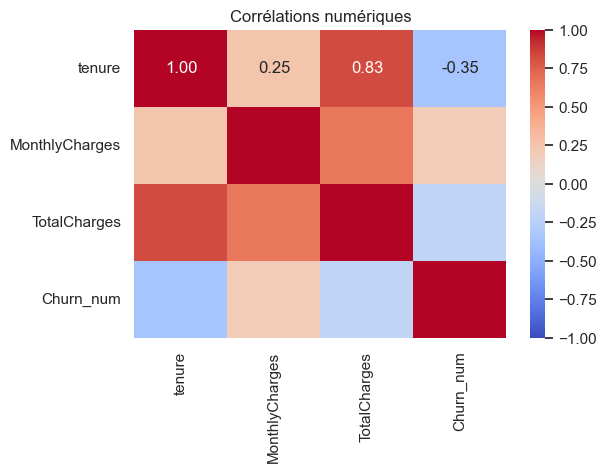

In [26]:
# Encoder Churn temporairement pour la heatmap
df_corr = df.copy()
df_corr['Churn_num'] = (df_corr['Churn'] == 'Yes').astype(int)

corr_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_num']
plt.figure(figsize=(6, 4))
sns.heatmap(df_corr[corr_cols].corr(),
            annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1)
plt.title('Corrélations numériques')
plt.show()

### Analyse case par case avec Churn_num 
#### tenure → Churn : -0.35  :
- Corrélation négative — plus le client est ancien, moins il churne
- Corrélation négative — plus le client est ancien, moins il churne

#### MonthlyCharges → Churn : valeur pâle (~+0.19)
- Corrélation positive faible — facture élevée = légèrement plus de churn
- L'effet existe mais est modéré seul

#### TotalCharges → Churn : légèrement bleu (~-0.20)
- Corrélation négative faible — car TotalCharges est lié au tenure (clients anciens = grosse facture totale = moins de churn)

# Boxplots — numériques vs Churn

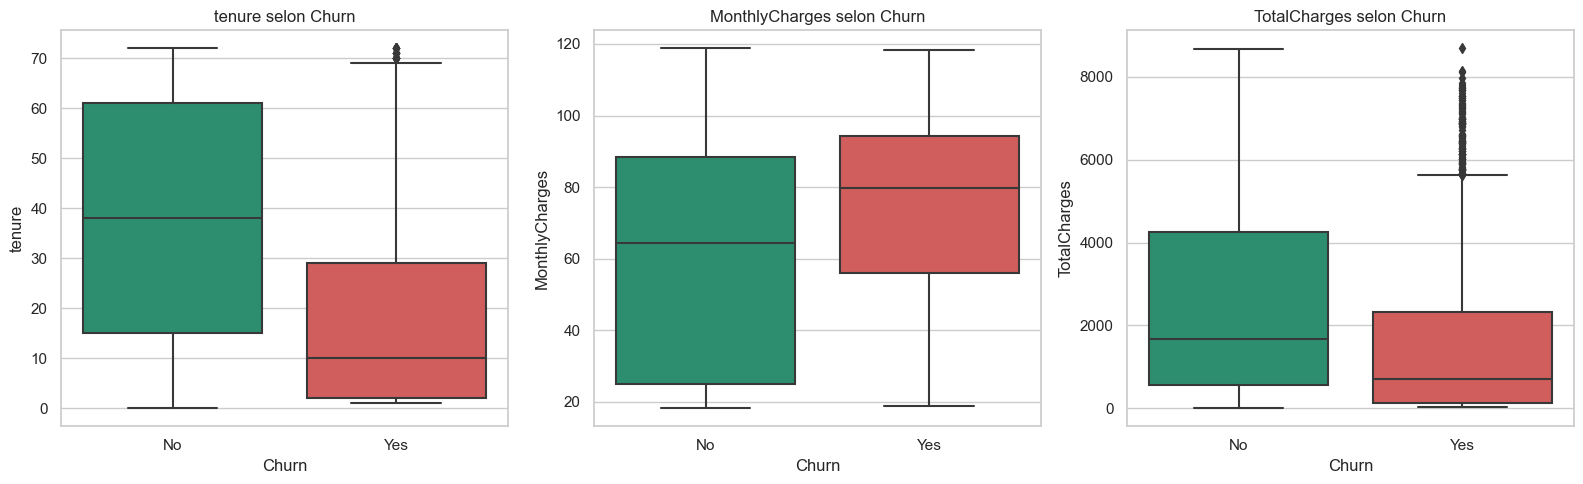

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x='Churn', y=col,
                palette=['#1D9E75', '#E24B4A'], ax=axes[i])
    axes[i].set_title(f'{col} selon Churn')

plt.tight_layout()
plt.show()

####  Boxplot 1 — tenure selon Churn
- No Churn (vert) : médiane ~35 mois, boîte large (10-55 mois)
- Churn (rouge) : médiane ~10 mois, boîte très basse (1-29 mois)
- la différence est énorme — un client fidèle a en médiane 3x plus d'ancienneté qu'un client qui part

#### Boxplot 2 — MonthlyCharges selon Churn
- No Churn (vert) : médiane ~65, boîte entre 30-85 
- Churn (rouge) : médiane ~80, boîte entre 60-100
-  les clients qui churned paient ~15 de plus par mois en médiane — l'offre ne justifie pas son prix pour eux

#### Boxplot 3 — TotalCharges selon Churn 
- No Churn (vert) : médiane ~1800, boîte très large jusqu'à 4200
- Churn (rouge) : médiane ~700,boîte basse (200-2200)
- Point isolé à ~8500 chez les churners → un outlier rare
- conséquence directe du tenure court — pas eu le temps d'accumuler

## Suppression des colonnes inutiles

In [28]:
# customerID = identifiant, TotalCharges = redondante
df = df.drop(columns=['customerID', 'TotalCharges'])
print("Colonnes restantes :", df.shape[1])
print(df.columns.tolist())

Colonnes restantes : 19
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'Churn']


### Suppression de TotalCharges avant l'encodage

TotalCharges est fortement corrélé avec Tenure (corrélation de 0,83, comme montré dans la heatmap).  
Cela signifie que **ces deux variables contiennent presque la même information**.  

Conserver les deux pourrait créer :  
- **Redondance** : le modèle apprend deux fois la même relation, ce qui n’apporte pas d’information supplémentaire.  
- **Multicolinéarité** : certaines méthodes (ex. régression) peuvent être perturbées si deux variables sont très corrélées.  
- **Complexité inutile** : plus de variables = modèle plus complexe et risque de surapprentissage.  

Donc, avant l’encodage, on supprime TotalCharges pour simplifier le modèle tout en conservant l’information essentielle via Tenure.

## Encodage binaire — Label Encoding (Yes/No → 1/0)

In [29]:
# Colonnes avec uniquement Yes/No
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService',
               'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
               'DeviceProtection', 'TechSupport', 'StreamingTV',
               'StreamingMovies', 'PaperlessBilling']

for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0,
                           'Female': 1, 'Male': 0})

# Variable cible
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
print("Encodage binaire OK ")

Encodage binaire OK 


## One-Hot Encoding — colonnes multi-catégorielles

In [30]:
# Colonnes avec 3+ modalités
multi_cols = ['InternetService', 'Contract', 'PaymentMethod']
df = pd.get_dummies(df, columns=multi_cols, drop_first=True)
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)
print("One-Hot Encoding OK ")
print("Nouvelles colonnes :", df.shape[1])
print(df.columns.tolist())

One-Hot Encoding OK 
Nouvelles colonnes : 23
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'Churn', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


#### La logique du drop_first=True
- Quand Fiber optic = 0 et No = 0 → le modèle sait automatiquement que c'est DSL. Pas besoin de la colonne.

Si on garde toutes les colonnes, elles sont parfaitement corrélées entre elles (leur somme = toujours 1), ce qui casse les modèles linéaires comme la Régression Logistique — c'est le dummy variable trap.


## Normalisation des variables numériques

In [31]:
scaler = StandardScaler()
num_cols = ['tenure', 'MonthlyCharges']

df[num_cols] = scaler.fit_transform(df[num_cols])
print("Normalisation OK ")
df[num_cols].describe().round(2)

Normalisation OK 


,tenure,MonthlyCharges
count,7043.00,7043.00
mean,-0.00,-0.00
std,1.00,1.00
min,-1.32,-1.55
25%,-0.95,-0.97
50%,-0.14,0.19
75%,0.92,0.83
max,1.61,1.79


Sans normalisation, un modèle pourrait donner plus d'importance à MonthlyCharges (valeurs 18-118) qu'à tenure (valeurs 0-72) juste à cause de l'échelle, pas de la vraie importance de la variable.

##  Vérification finale du dataset

In [32]:
# ---- Vérification finale ----
print("Shape :", df.shape)
print("NaN restants :", df.isnull().sum().sum())
df.head(3)

Shape : (7043, 23)
NaN restants : 0


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,MonthlyCharges,Churn,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0,1,0,-1.277445,0,0,0,1,0,0,0,0,1,-1.160323,0,0,0,0,0,0,1,0
1,0,0,0,0,0.066327,1,0,1,0,1,0,0,0,0,-0.259629,0,0,0,1,0,0,0,1
2,0,0,0,0,-1.236724,1,0,1,1,0,0,0,0,1,-0.362660,1,0,0,0,0,0,0,1


# Modélisation

###  Imports & séparation X / y

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report,
                                 confusion_matrix, roc_auc_score,
                                 RocCurveDisplay)

# Séparation features / cible
X = df.drop(columns=['Churn'])
y = df['Churn']

# Split 80% train / 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y) 
print(f"Train : {X_train.shape[0]} lignes")
print(f"Test : {X_test.shape[0]} lignes")

Train : 5634 lignes
Test : 1409 lignes


 - stratify=y → même ratio Churn 73/27 dans train et test, 
 on force le split à respecter les proportions de Churn

###  Régression Logistique

In [34]:
lr = LogisticRegression(max_iter=1000, class_weight='balanced',
                       random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("=== Régression Logistique ===")
print(classification_report(y_test, y_pred_lr))
print("AUC-ROC :", roc_auc_score(y_test, lr.predict_proba(X_test)[:,1]).round(3))

=== Régression Logistique ===
              precision    recall  f1-score   support

           0       0.90      0.73      0.81      1035
           1       0.51      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

AUC-ROC : 0.839


- class_weight='balanced' corrige le déséquilibre 73/27

### Random Forest

In [35]:
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                           random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf))
print("AUC-ROC :", roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]).round(3))

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1035
           1       0.63      0.47      0.53       374

    accuracy                           0.78      1409
   macro avg       0.73      0.68      0.70      1409
weighted avg       0.77      0.78      0.77      1409

AUC-ROC : 0.82


### Matrices de confusion

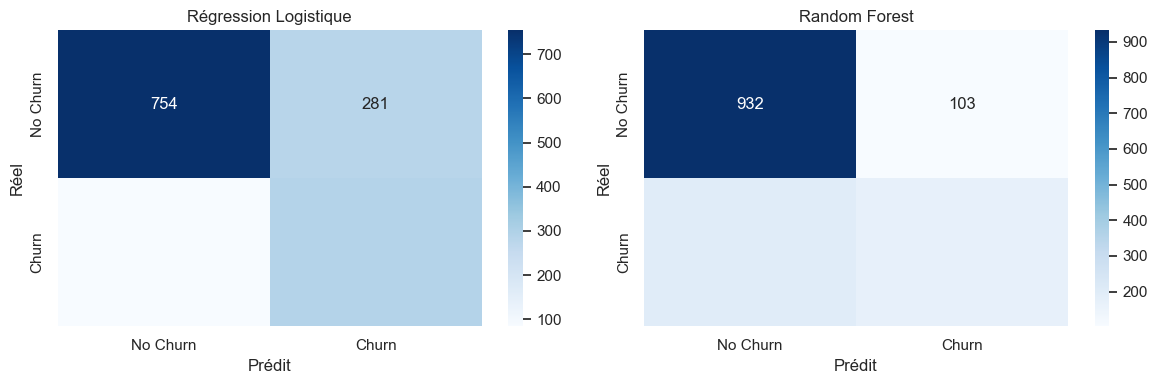

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, model, preds, title in zip(
    axes,
    [lr, rf],
    [y_pred_lr, y_pred_rf],
    ['Régression Logistique', 'Random Forest']):

    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Churn', 'Churn'],
                yticklabels=['No Churn', 'Churn'], ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Prédit')
    ax.set_ylabel('Réel')

plt.tight_layout()
plt.show()

### Importance des variables

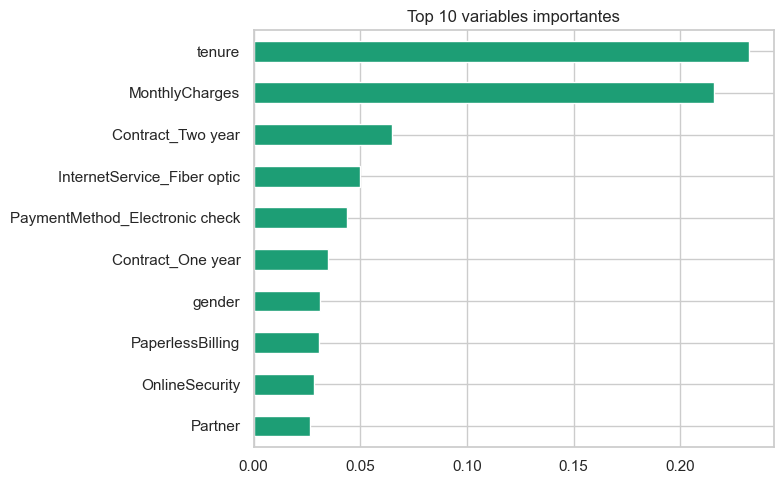

In [37]:
importances = pd.Series(rf.feature_importances_,
                          index=X.columns)
importances.sort_values(ascending=False).head(10).plot(
    kind='barh', figsize=(8, 5),
    color='#1D9E75', title='Top 10 variables importantes')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

###  Ajustement du seuil — Régression Logistique
On cherche le seuil qui maximise le recall sans trop sacrifier la precision

In [38]:
import numpy as np
from sklearn.metrics import precision_recall_curve

# Probabilités prédites
y_proba_lr = lr.predict_proba(X_test)[:,1]

# Tester plusieurs seuils
thresholds = np.arange(0.2, 0.6, 0.05)
print(f"{'Seuil':>8} {'Precision':>10} {'Recall':>8} {'F1':>8}")
print("-" * 40)

from sklearn.metrics import precision_score, recall_score, f1_score
for thresh in thresholds:
    y_pred_t = (y_proba_lr >= thresh).astype(int)
    p = precision_score(y_test, y_pred_t)
    r = recall_score(y_test, y_pred_t)
    f = f1_score(y_test, y_pred_t)
    print(f"{thresh:>8.2f} {p:>10.3f} {r:>8.3f} {f:>8.3f}")

   Seuil  Precision   Recall       F1
----------------------------------------
    0.20      0.390    0.963    0.555
    0.25      0.405    0.939    0.566
    0.30      0.432    0.930    0.590
    0.35      0.446    0.898    0.596
    0.40      0.467    0.858    0.605
    0.45      0.484    0.816    0.608
    0.50      0.508    0.775    0.614
    0.55      0.526    0.743    0.616


### Appliquer le meilleur seuil

In [39]:
best_thresh = 0.45
y_pred_lr_tuned = (y_proba_lr >= best_thresh).astype(int)

print(f"=== LR avec seuil {best_thresh} ===")
print(classification_report(y_test, y_pred_lr_tuned,
      target_names=['No Churn', 'Churn']))
print("AUC-ROC :", roc_auc_score(y_test, y_proba_lr).round(3))

=== LR avec seuil 0.45 ===
              precision    recall  f1-score   support

    No Churn       0.91      0.69      0.78      1035
       Churn       0.48      0.82      0.61       374

    accuracy                           0.72      1409
   macro avg       0.70      0.75      0.70      1409
weighted avg       0.80      0.72      0.74      1409

AUC-ROC : 0.839


- Avec un seuil de 0.45, on détecte 15 churners supplémentaires qui auraient été ratés.  
Si chaque client vaut 500 dollars par an, cela représente un gain potentiel de 7500 dollars de revenus sauvegardés.

- En contrepartie, on envoie des offres de rétention à quelques clients supplémentaires qui n'allaient pas partir (faux positifs) — coût faible et acceptable.


### Cross-Validation — vérifier la robustesse

In [40]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for model, name in [(lr, 'Régression Logistique'),
                      (rf, 'Random Forest')]:
    scores = cross_val_score(model, X, y,
                            cv=cv, scoring='roc_auc')
    print(f"{name}")
    print(f" AUC-ROC : {scores.mean():.3f} (+/- {scores.std():.3f})\n")

Régression Logistique
 AUC-ROC : 0.843 (+/- 0.014)

Random Forest
 AUC-ROC : 0.815 (+/- 0.015)



#### Résultats Cross-Validation

- **Régression Logistique** : AUC-ROC = 0.843 (+/- 0.014)  
  → Modèle très stable et performant  
  → Bonne généralisation (pas de surapprentissage)

- **Random Forest** : AUC-ROC = 0.815 (+/- 0.015)  
  → Stable mais moins performant  

La Régression Logistique est le meilleur modèle pour ce dataset.

#### Pourquoi la LR bat le Random Forest ici ?
Ce dataset de Churn télécom a des relations quasi-linéaires entre les features et le Churn — par exemple plus le tenure est long, moins le churn est probable. La Régression Logistique excelle dans ces cas. Le Random Forest est plus utile quand les relations sont complexes et non-linéaires.

In [42]:
from xgboost import XGBClassifier

# Ratio pour corriger le déséquilibre
scale = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(n_estimators=200,
                    scale_pos_weight=scale,
                    learning_rate=0.05,
                    max_depth=4,
                    random_state=42,
                    eval_metric='logloss')
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
print("=== XGBoost ===")
print(classification_report(y_test, y_pred_xgb,
      target_names=['No Churn', 'Churn']))
print("AUC-ROC :", roc_auc_score(
    y_test, xgb.predict_proba(X_test)[:,1]).round(3))


=== XGBoost ===
              precision    recall  f1-score   support

    No Churn       0.91      0.73      0.81      1035
       Churn       0.51      0.80      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409

AUC-ROC : 0.841


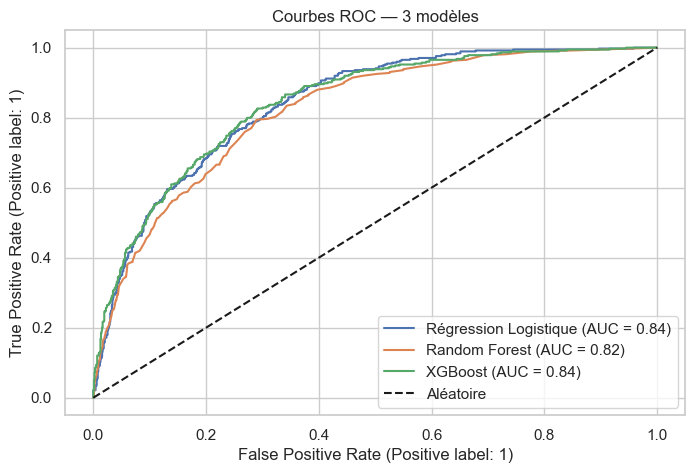

In [43]:
fig, ax = plt.subplots(figsize=(8, 5))

for model, name in [
    (lr, 'Régression Logistique'),
    (rf, 'Random Forest'),
    (xgb, 'XGBoost')]:
    RocCurveDisplay.from_estimator(
        model, X_test, y_test, name=name, ax=ax)

ax.plot([0,1], [0,1], 'k--', label='Aléatoire')
ax.set_title('Courbes ROC — 3 modèles')
plt.legend()
plt.show()

- XGBoost (0.841) et LR (0.839) sont pratiquement à égalité — la différence est négligeable. Sur ce dataset, les relations sont suffisamment linéaires pour que la LR soit aussi performante qu'un modèle complexe comme XGBoost, avec l'avantage d'être plus simple, plus rapide et plus interprétable.

In [44]:
# Identifier les clients à risque dans le dataset complet
df['Churn_Proba'] = lr.predict_proba(X)[:,1]
df['Churn_Predit'] = (df['Churn_Proba'] >= 0.45).astype(int)

# Segmenter par niveau de risque
df['Risque'] = pd.cut(df['Churn_Proba'],
                      bins=[0, 0.3, 0.5, 0.7, 1.0],
                      labels=['Faible', 'Modéré', 'Élevé', 'Critique'])

print(df['Risque'].value_counts())

Risque
Faible      2998
Critique    1756
Modéré      1192
Élevé       1097
Name: count, dtype: int64


## Segmentation Marketing


### Objectif
Transformer les scores de probabilité du modèle en segments 
actionnables pour l'équipe marketing.


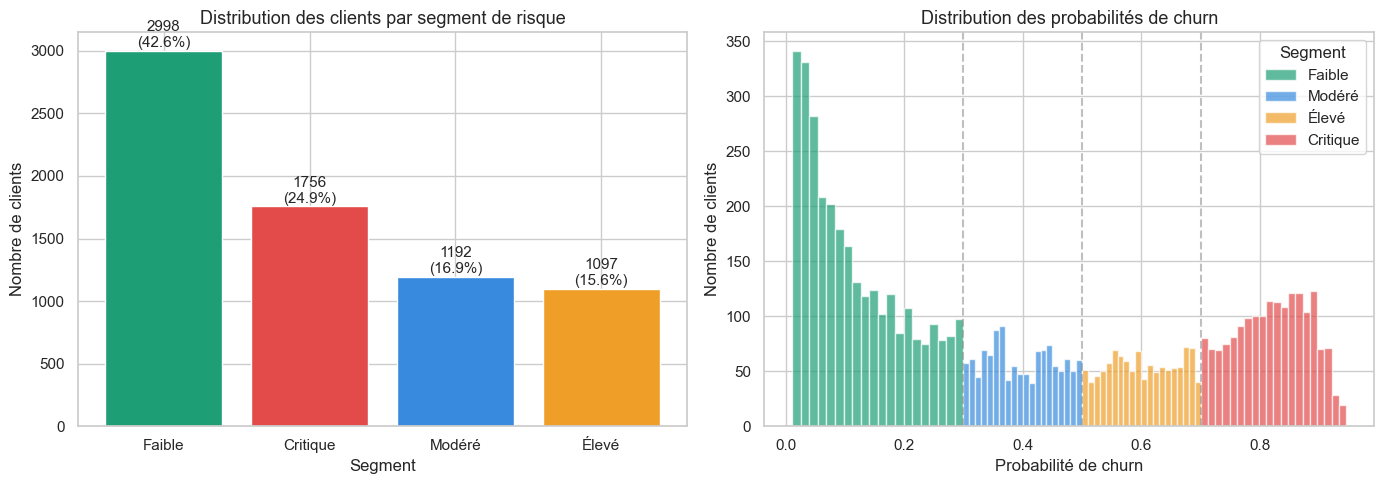


=== Profil moyen par segment ===
          tenure  MonthlyCharges  Churn_Proba
Risque                                       
Faible     49.23           55.95         0.12
Modéré     27.12           58.74         0.40
Élevé      23.63           68.92         0.60
Critique   12.62           81.29         0.82

Fichier exporté : plan_marketing_segments.csv
      customerID        Contract InternetService  tenure  MonthlyCharges  \
1976  9497-QCMMS  Month-to-month     Fiber optic       1           93.55   
3380  5178-LMXOP  Month-to-month     Fiber optic       1           95.10   
4800  9300-AGZNL  Month-to-month     Fiber optic       1           94.00   
6368  2720-WGKHP  Month-to-month     Fiber optic       2           94.00   
3749  4424-TKOPW  Month-to-month     Fiber optic       2           93.85   
2208  7216-EWTRS  Month-to-month     Fiber optic       1          100.80   
5989  5567-WSELE  Month-to-month     Fiber optic       3           94.60   
1410  7024-OHCCK  Month-to-month   

In [47]:
# Recharger customerID depuis le fichier original
df_original = pd.read_csv(r"C:\Users\MEROUA\Desktop\Le_Churn\data\data.csv")

# Ajouter les infos utiles pour le marketing
df_export = pd.DataFrame({
    'customerID'     : df_original['customerID'],
    'Contract'       : df_original['Contract'],
    'InternetService': df_original['InternetService'],
    'tenure'         : df_original['tenure'],
    'MonthlyCharges' : df_original['MonthlyCharges'],
    'PaymentMethod'  : df_original['PaymentMethod'],
    'Churn_Proba'    : df['Churn_Proba'].round(3),
    'Risque'         : df['Risque']
})

# ---- Ajouter les actions marketing ----
def definir_action(risque):
    if risque == 'Critique':
        return "Appel client + remise 20% + proposer contrat annuel"
    elif risque == 'Élevé':
        return "Email + offre 1 mois gratuit"
    elif risque == 'Modéré':
        return "Campagne fidélité automatique"
    else:  # Faible
        return "Programme parrainage / upsell"

df_export['Action_marketing'] = df_export['Risque'].apply(definir_action)

# ---- Trier par risque décroissant ----
df_export = df_export.sort_values('Churn_Proba', ascending=False)

# ---- Visualisation des 4 segments ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphique 1 : Distribution des segments
colors = {'Critique': '#E24B4A', 'Élevé': '#EF9F27',
          'Modéré': '#378ADD', 'Faible': '#1D9E75'}

segment_counts = df_export['Risque'].value_counts()
bars = axes[0].bar(segment_counts.index,
                   segment_counts.values,
                   color=[colors[r] for r in segment_counts.index])

axes[0].set_title('Distribution des clients par segment de risque', fontsize=13)
axes[0].set_ylabel('Nombre de clients')
axes[0].set_xlabel('Segment')

# Ajouter les valeurs sur les barres
for bar, val in zip(bars, segment_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 30,
                 f'{val}\n({val/len(df_export)*100:.1f}%)',
                 ha='center', fontsize=11)

# Graphique 2 : Distribution des probabilités
axes[1].hist(df_export[df_export['Risque']=='Faible']['Churn_Proba'],
             bins=20, alpha=0.7, color='#1D9E75', label='Faible')
axes[1].hist(df_export[df_export['Risque']=='Modéré']['Churn_Proba'],
             bins=20, alpha=0.7, color='#378ADD', label='Modéré')
axes[1].hist(df_export[df_export['Risque']=='Élevé']['Churn_Proba'],
             bins=20, alpha=0.7, color='#EF9F27', label='Élevé')
axes[1].hist(df_export[df_export['Risque']=='Critique']['Churn_Proba'],
             bins=20, alpha=0.7, color='#E24B4A', label='Critique')

axes[1].set_title('Distribution des probabilités de churn', fontsize=13)
axes[1].set_xlabel('Probabilité de churn')
axes[1].set_ylabel('Nombre de clients')
axes[1].legend(title='Segment')
axes[1].axvline(x=0.3, color='gray', linestyle='--', alpha=0.5)
axes[1].axvline(x=0.5, color='gray', linestyle='--', alpha=0.5)
axes[1].axvline(x=0.7, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# ---- Tableau récapitulatif par segment ----
print("\n=== Profil moyen par segment ===")
print(df_export.groupby('Risque')[['tenure', 'MonthlyCharges', 'Churn_Proba']].mean().round(2))

# ---- Export CSV ----
df_export.to_csv('plan_marketing_segments.csv', index=False)
print("\nFichier exporté : plan_marketing_segments.csv")
print(df_export.head(10))


### Segments définis
| Segment  | Probabilité | Clients | Action |
|----------|-------------|---------|--------|
| 🔴 Critique | > 70%    | 1756    | Appel immédiat + offre personnalisée |
| 🟠 Élevé    | 50-70%   | 1097    | Email urgent + SMS |
| 🔵 Modéré   | 30-50%   | 1192    | Campagne email automatique |
| 🟢 Faible   | < 30%    | 2998    | Fidélisation + upsell |

### Profil type du client critique
- Nouveau client (tenure < 13 mois en moyenne)
- Abonnement Fiber optic
- Contrat Month-to-month
- Facture > 80$/mois
- Paiement par Electronic check